In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Loading data
raw_welfare = pd.read_spss('./data/Koweps_hpwc14_2019_beta2.sav')

# Make a copy
welfare = raw_welfare.copy()

In [3]:
print(f"Dataset shape: {welfare.shape}")

Dataset shape: (14418, 830)


In [4]:
# Rename some columns
welfare = welfare.rename(
    columns = {'h14_g3': 'gender',
               'h14_g4': 'birth_year',
               'h14_g10': 'marriage_type',
               'h14_g11': 'religion',
               'p1402_8aq1': 'income',
               'h14_eco9': 'code_job',
               'h14_reg7': 'code_region'}
)

# 01. Gender Wage Gap Analysis

### Research Question
    In the Exploratory Data Analysis (EDA), male respondents showed a considerably higher average income than female respondents. However, an observed difference in sample means does not necessarily imply that the same difference exists in the population. The objective of this analysis is to determine whether the observed income difference between male and female respondents is statistically significant.

### Why Statistical Testing?
    Descriptive statistics summarize the sample, but they cannot determine whether an observed difference is due to random sampling variation. Therefore, a statistical hypothesis test is required to evaluate whether the observed income gap between male and female respondents is statistically significant.

In [5]:
welfare['gender'] = np.where( welfare['gender']==1, 'male', 'female' )

In [6]:
welfare['gender'].value_counts()

gender
female    7913
male      6505
Name: count, dtype: int64

In [7]:
welfare_income = welfare.dropna(subset=['income']).copy()

In [8]:
welfare_income.groupby( 'gender', as_index=False ).agg( gender_mean=('income','mean') ).round(2)

,gender,gender_mean
0,female,186.29
1,male,349.04


In [9]:
# Separate income data by gender
male_income = welfare_income.loc[welfare_income['gender'] == 'male', 'income']
female_income = welfare_income.loc[welfare_income['gender'] == 'female', 'income']

In [10]:
# Display descriptive statistics
gender_income_summary = (
    welfare_income
    .groupby( 'gender', as_index=False )
    .agg(
        sample_size=( 'income', 'count' ),
        mean_income=( 'income', 'mean' ),
        median_income=( 'income', 'median' ),
        std_income=( 'income', 'std' )
    )    .round(2)
)

gender_income_summary

,gender,sample_size,mean_income,median_income,std_income
0,female,2245,186.29,178.0,132.06
1,male,2289,349.04,301.0,217.86


In [11]:
t_stat, p_value = stats.ttest_ind( male_income, female_income, equal_var=False )

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

T-statistic: 30.4829
P-value: 1.1042e-182


#### Why was Welch's t-test selected? (equal_var=False)
- The objective of this analysis is to compare the mean income between two independent groups: male and female respondents. Welch's t-test was selected because it does not assume equal variances between the two groups. Since real-world income data often have unequal variances and unequal sample sizes, Welch's t-test is generally considered more robust than Student's t-test.

- Hypotheses<br>
&nbsp;&nbsp;&nbsp;&nbsp;<b>Null Hypothesis (H₀)</b><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;The mean income of male and female respondents is equal.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<i>`H₀: μmale = μfemale`</i><br><br>
&nbsp;&nbsp;&nbsp;&nbsp;<b>Alternative Hypothesis (H₁)</b><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;The mean income of male and female respondents is different.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`H₁: μmale ≠ μfemale`

In [12]:
alpha = 0.05

if p_value < alpha:
    print( "Reject the null hypothesis. "
           "The mean income difference between male and female respondents "
           "is statistically significant." )
else:
    print( "Fail to reject the null hypothesis. "
           "There is insufficient evidence of a statistically significant "
           "difference in mean income." )

Reject the null hypothesis. The mean income difference between male and female respondents is statistically significant.


### Interpretation

Since the p-value is substantially smaller than the significance level (α = 0.05), the null hypothesis is rejected.
This indicates that the difference in the mean income between male and female respondents is statistically significant.

## <b><u>Conclusion</u></b>

The analysis suggests that male and female respondents have significantly different average incomes in this dataset. However, this result does not imply that gender alone causes the income difference. Other factors, such as age, occupation, education, and work experience, may also contribute to the observed income gap. Further analyses incorporating multiple variables would provide a more comprehensive understanding of this relationship.

---

# 02. Divorce Rates by Religion: Is Religion Associated with Divorce Rate?

## Research Question
    The exploratory analysis showed that respondents with a religion had a lower divorce rate (7.95%) than those without a religion (9.50%). However, an observed difference in sample divorce rates does not necessarily indicate that the same difference exists in the population. The observed gap may simply be the result of random sampling variation. The objective of this analysis is to determine whether the observed difference in divorce rates between respondents with and without religion is statistically significant.

### Why Statistical Testing?
    The exploratory analysis showed that respondents with a religion had a lower divorce rate (7.95%) than those without a religion (9.50%). However, an observed difference in sample proportions does not necessarily imply that the same difference exists in the population. The observed gap may simply be due to random sampling variation. Statistical hypothesis testing was therefore performed to determine whether the observed difference in divorce rates is statistically significant.

In [13]:
welfare['religion'] = np.where( welfare['religion']==1, 'yes', 'no' )
welfare['religion'].value_counts()

religion
no     7815
yes    6603
Name: count, dtype: int64

In [14]:
welfare['marriage'] = np.where( welfare['marriage_type']==1, 'married',
                                     np.where( welfare['marriage_type']==3, 'divorced', 'etc'))

cnt_marriage_status = welfare.groupby( 'marriage', as_index=False ).\
    agg( n_marriage_status=('marriage','count') )

cnt_marriage_status

,marriage,n_marriage_status
0,divorced,689
1,etc,6539
2,married,7190


In [15]:
religion_marriage_proportion  = welfare.query( 'marriage!="etc"' ).groupby( 'religion', as_index=False )['marriage']\
    .value_counts( normalize=True )
religion_marriage_proportion 

,religion,marriage,proportion
0,no,married,0.905045
1,no,divorced,0.094955
2,yes,married,0.920469
3,yes,divorced,0.079531


In [16]:
religion_divorce_rate  = religion_marriage_proportion.query( 'marriage=="divorced"' )\
    .assign( proportion=lambda x: x['proportion']*100 ).round(2)
religion_divorce_rate 

,religion,marriage,proportion
1,no,divorced,9.50
3,yes,divorced,7.95


In [17]:
welfare = welfare.assign( 
        marriage_status=(
                lambda x: np.where(
                        x['marriage']=='married',
                        0,
                        np.where( 
                            x['marriage']=='divorced',
                            1,
                            9
                        )
                )
        )
)
welfare[['religion', 'marriage', 'marriage_status']].head()

,religion,marriage,marriage_status
0,yes,etc,9
1,no,etc,9
2,yes,divorced,1
3,yes,married,0
4,yes,married,0


In [18]:
religious_group = welfare.query('religion=="yes" & marriage_status!=9')['marriage_status']
religious_group

2        1
3        0
4        0
6        0
7        0
        ..
14402    0
14410    0
14411    0
14412    0
14413    0
Name: marriage_status, Length: 3835, dtype: int64

In [19]:
non_religious_group = welfare.query('religion=="no" & marriage_status!=9')['marriage_status']
non_religious_group

11       0
12       0
14       0
15       0
23       0
        ..
14396    0
14397    0
14399    0
14407    0
14408    0
Name: marriage_status, Length: 4044, dtype: int64

In [20]:
t_stat, p_value = stats.ttest_ind( religious_group, non_religious_group, equal_var=False )

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

T-statistic: -2.4283
P-value: 1.5193e-02


## Why Welch's t-test?
To compare divorce rates between the two groups, marital status was encoded as a binary variable:
- Married = 0
- Divorced = 1

With this encoding, the mean of each group represents its divorce rate. Therefore, comparing the group means is equivalent to comparing the divorce rates. Since the two groups (respondents with and without religion) are independent and may have unequal variances, Welch's t-test was used to compare their mean divorce rates.

In [21]:
alpha = 0.05

if p_value < alpha:
    print(
        "Reject the null hypothesis. "
        "The difference in divorce rates between respondents "
        "with and without religion is statistically significant."
    )
else:
    print(
        "Fail to reject the null hypothesis. "
        "There is insufficient evidence of a statistically significant "
        "difference in divorce rates between respondents "
        "with and without religion."
    )

Reject the null hypothesis. The difference in divorce rates between respondents with and without religion is statistically significant.


### Interpretation
Since the p-value (0.0152) is smaller than the significance level of 0.05, the null hypothesis is rejected.
This suggests that the observed difference in divorce rates between respondents with and without religion is unlikely to be explained by random sampling variation alone. Respondents with a religion had a lower divorce rate (7.95%) than those without a religion (9.50%).

## <b><u>Conclusion</u></b>
A statistically significant difference in divorce rates was observed between respondents with and without religion.
However, this analysis does not establish a causal relationship between religion and divorce. Since only one variable was considered, other factors may explain the observed difference.
Future analyses using additional variables and more advanced statistical methods would provide a more comprehensive understanding of the factors associated with divorce.

> **Note:**  
> Since this project focuses on learning t-tests, a Welch's t-test was used to compare the mean divorce rates between the two groups. In practice, a Chi-square test is generally more appropriate for analyzing the relationship between two categorical variables such as religion and marital status.

---

# 03. Correlation between Age and Income

## Research Question
    Is there a statistically significant correlation between age and income?

## Why Correlation Analysis?
    Both age and income are continuous numerical variables. Pearson's correlation analysis is an appropriate statistical method for examining whether a linear relationship exists between these two variables and for measuring the strength and direction of that relationship.

In [22]:
welfare_age_income = welfare.assign( age=( 2019 - welfare['birth_year'] ) )
welfare_age_income[ ['birth_year', 'age'] ].head()

,birth_year,age
0,1945.0,74.0
1,1948.0,71.0
2,1942.0,77.0
3,1962.0,57.0
4,1963.0,56.0


## Why Pearson's Correlation?
    Pearson's correlation coefficient was used because both variables are continuous and the objective of this analysis is to determine whether age and income have a linear relationship. In addition to measuring the strength and direction of the relationship, Pearson's correlation also provides a p-value to evaluate its statistical significance.

- Hypotheses<br>
&nbsp;&nbsp;&nbsp;&nbsp;<b>Null Hypothesis (H₀)</b><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;There is no statistically significant linear correlation between age and income.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<i>`H₀: ρ = 0`</i><br><br>
&nbsp;&nbsp;&nbsp;&nbsp;<b>Alternative Hypothesis (H₁)</b><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;There is a statistically significant linear correlation between age and income.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`H₁: ρ ≠ 0`

In [23]:
welfare_age_income = welfare_age_income.dropna( subset=['age', 'income'] ).copy()

In [24]:
r_value, p_value = stats.pearsonr( welfare_age_income['age'], welfare_age_income['income'] )

In [25]:
print(f"Correlation coefficient (r): {r_value:.4f}")
print(f"P-value: {p_value:.4e}")

Correlation coefficient (r): -0.2195
P-value: 1.3433e-50


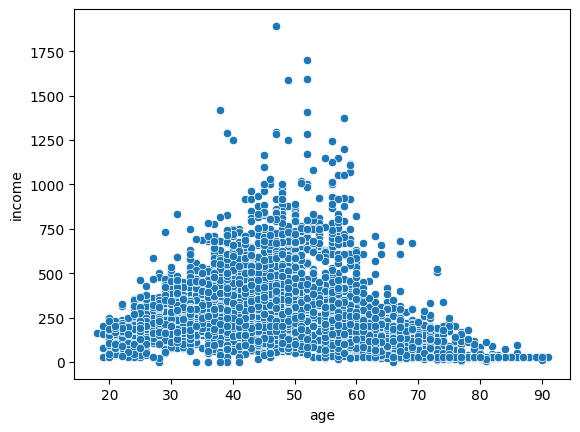

In [26]:
sns.scatterplot( data=welfare_age_income,
                 x='age',
                 y='income' );

### Interpretation
Since the p-value (1.3433e-50) is much smaller than the significance level of 0.05, the null hypothesis is rejected.
The Pearson correlation coefficient (r = -0.2195) indicates a weak negative linear relationship between age and income. This suggests that, overall, income tends to decrease slightly as age increases. Although the relationship is statistically significant, its strength is relatively weak.

## <b><u>Conclusion</u></b>
A statistically significant correlation was found between age and income. However, the correlation coefficient indicates only a weak negative linear relationship.
The scatter plot also suggests that the relationship between age and income is not perfectly linear. Therefore, while Pearson's correlation detects a statistically significant association, it may not fully represent the overall pattern between these two variables.

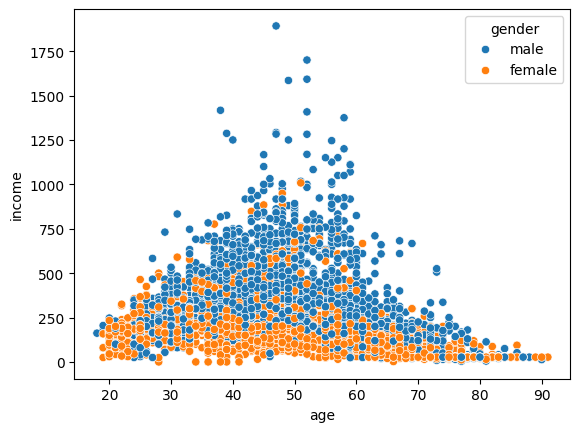

In [27]:
sns.scatterplot( data=welfare_age_income,
                 x='age',
                 y='income',
                 hue='gender' );

### Additional Observation: Income Distribution by Gender
    When the scatter plot is colored by gender, female respondents appear to be more concentrated in the lower-income range than male respondents. This visual pattern is consistent with the results of the previous Welch's t-test, which found a statistically significant difference in income between males and females. Although this scatter plot alone does not establish statistical significance, it provides visual evidence that supports the earlier statistical findings.

---

# 04. Age vs. Income (Respondents Younger Than 50)

## Research Question
    Is there a statistically significant correlation between age and income among respondents younger than 50 years old?

## Why Subgroup Correlation Analysis?
    The scatter plot for all respondents suggests that the relationship between age and income may differ before and after middle age. Therefore, respondents younger than 50 years old were analyzed separately to examine the linear relationship within this age group.

- Hypotheses<br>
&nbsp;&nbsp;&nbsp;&nbsp;<b>Null Hypothesis (H₀)</b><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;There is no linear correlation between age and income within this age group.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<i>`H₀: ρ = 0`</i><br><br>
&nbsp;&nbsp;&nbsp;&nbsp;<b>Alternative Hypothesis (H₁)</b><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;There is a linear correlation between age and income within this age group.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`H₁: ρ ≠ 0`

In [28]:
wel_df_upto_middle_age = welfare_age_income[ welfare_age_income['age']<50 ]

In [29]:
r_value, p_value = stats.pearsonr( wel_df_upto_middle_age['age'], wel_df_upto_middle_age['income'] )
print(f"Correlation coefficient (r): {r_value:.4f}")
print(f"P-value: {p_value:.4e}")

Correlation coefficient (r): 0.3422
P-value: 1.2256e-72


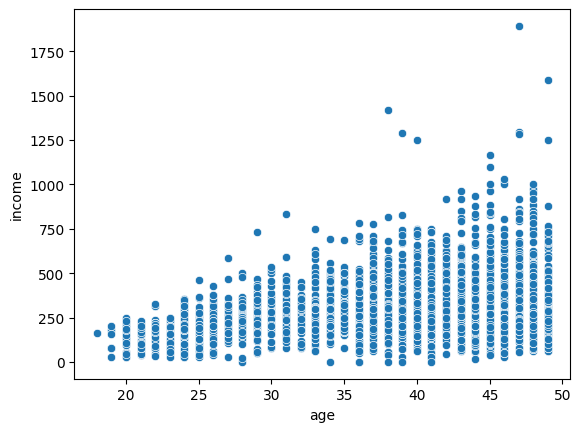

In [30]:
sns.scatterplot( data=wel_df_upto_middle_age,
                 x='age',
                 y='income' );

### Interpretation

Since the p-value (1.2256e-72) is much smaller than the significance level of 0.05, the null hypothesis is rejected.
The Pearson correlation coefficient (r = 0.3422) indicates a weak-to-moderate positive linear relationship between age and income among respondents younger than 50 years old. This suggests that income generally tends to increase as age increases within this age group.

## <b><u>Conclusion</u></b>
A statistically significant positive correlation was found between age and income among respondents younger than 50 years old. Compared with the analysis using all age groups, the relationship becomes noticeably stronger when the analysis is limited to younger respondents. This suggests that the overall correlation observed across all ages may be influenced by differences in income patterns among older respondents.

### Additional Observation
    Compared with the previous analysis using all respondents (r = -0.2195), restricting the analysis to respondents younger than 50 years old produced a weak-to-moderate positive correlation (r = 0.3422). This suggests that the relationship between age and income differs across age groups. An analysis of respondents aged 50 and older may provide additional insight into how this relationship changes later in life.

---

# 05. Age vs. Income (Respondents Aged 50 and Older)

## Research Question
    Is there a statistically significant correlation between age and income among respondents aged 50 years and older?

## Why Subgroup Correlation Analysis?
    To examine whether the relationship changes after middle age, respondents aged 50 years and older were analyzed separately. This allows the direction and strength of the correlation in the older age group to be compared with those of younger respondents.

- Hypotheses<br>
&nbsp;&nbsp;&nbsp;&nbsp;<b>Null Hypothesis (H₀)</b><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;There is no linear correlation between age and income within this age group.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<i>`H₀: ρ = 0`</i><br><br>
&nbsp;&nbsp;&nbsp;&nbsp;<b>Alternative Hypothesis (H₁)</b><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;There is a linear correlation between age and income within this age group.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`H₁: ρ ≠ 0`

In [31]:
wel_df_senior = welfare_age_income[ welfare_age_income['age']>=50 ]

In [32]:
r_value, p_value = stats.pearsonr( wel_df_senior['age'], wel_df_senior['income'] )
print(f"Correlation coefficient (r): {r_value:.4f}")
print(f"P-value: {p_value:.4e}")

Correlation coefficient (r): -0.5074
P-value: 2.6980e-126


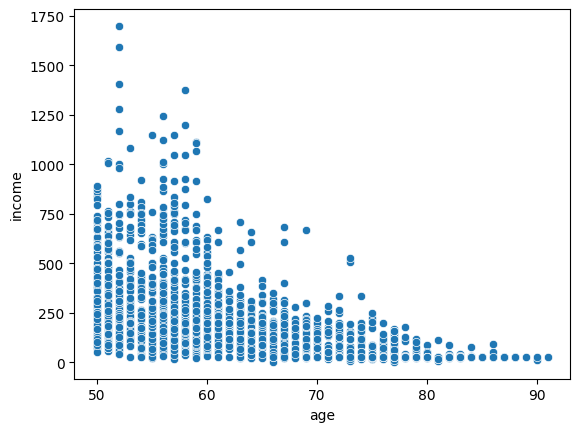

In [33]:
sns.scatterplot( data=wel_df_senior,
                 x='age',
                 y='income' );

### Interpretation

Since the p-value (2.6980e-126) is much smaller than the significance level of 0.05, the null hypothesis is rejected.
The Pearson correlation coefficient (r = -0.5074) indicates a moderate negative linear relationship between age and income among respondents aged 50 years and older. This suggests that income generally tends to decrease as age increases within this age group.

## <b><u>Conclusion</u></b>
A statistically significant negative correlation was found between age and income among respondents aged 50 years and older. Compared with the analysis of respondents younger than 50 years old, the direction of the relationship is reversed. This suggests that age and income follow different patterns before and after middle age.

### Additional Observation
#### &nbsp;&nbsp;&nbsp;&nbsp;Comparison with Previous Analyses
    Compared with the previous analyses, the direction of the relationship between age and income changes across age groups. Among respondents younger than 50 years old, age had a weak-to-moderate positive correlation with income (r = 0.3422), whereas among respondents aged 50 years and older, age was moderately negatively correlated with income (r = -0.5074). These findings explain why the correlation calculated using all respondents was relatively weak (r = -0.2195).